Loaded 527 relations and their embeddings from D:\\claimpkg\\claimpkg-clone\\src\\resources\\embeddings.
KG adjacency built. {'Hòa Bình Province': {'nickname': ['"Peace"'], 'northwest': ['Ninh Bình Province', 'Sơn La Province']}, 'Ngô Thị Doãn Thanh': {}, 'Sơn La Province': {'southwest': ['"Luang Prabang Province,"'], 'northwest': ['Lai Châu Province', 'Thanh Hóa Province']}, 'Affluence': {}, 'Nguyễn dynasty': {'capital': ['Huế']}}


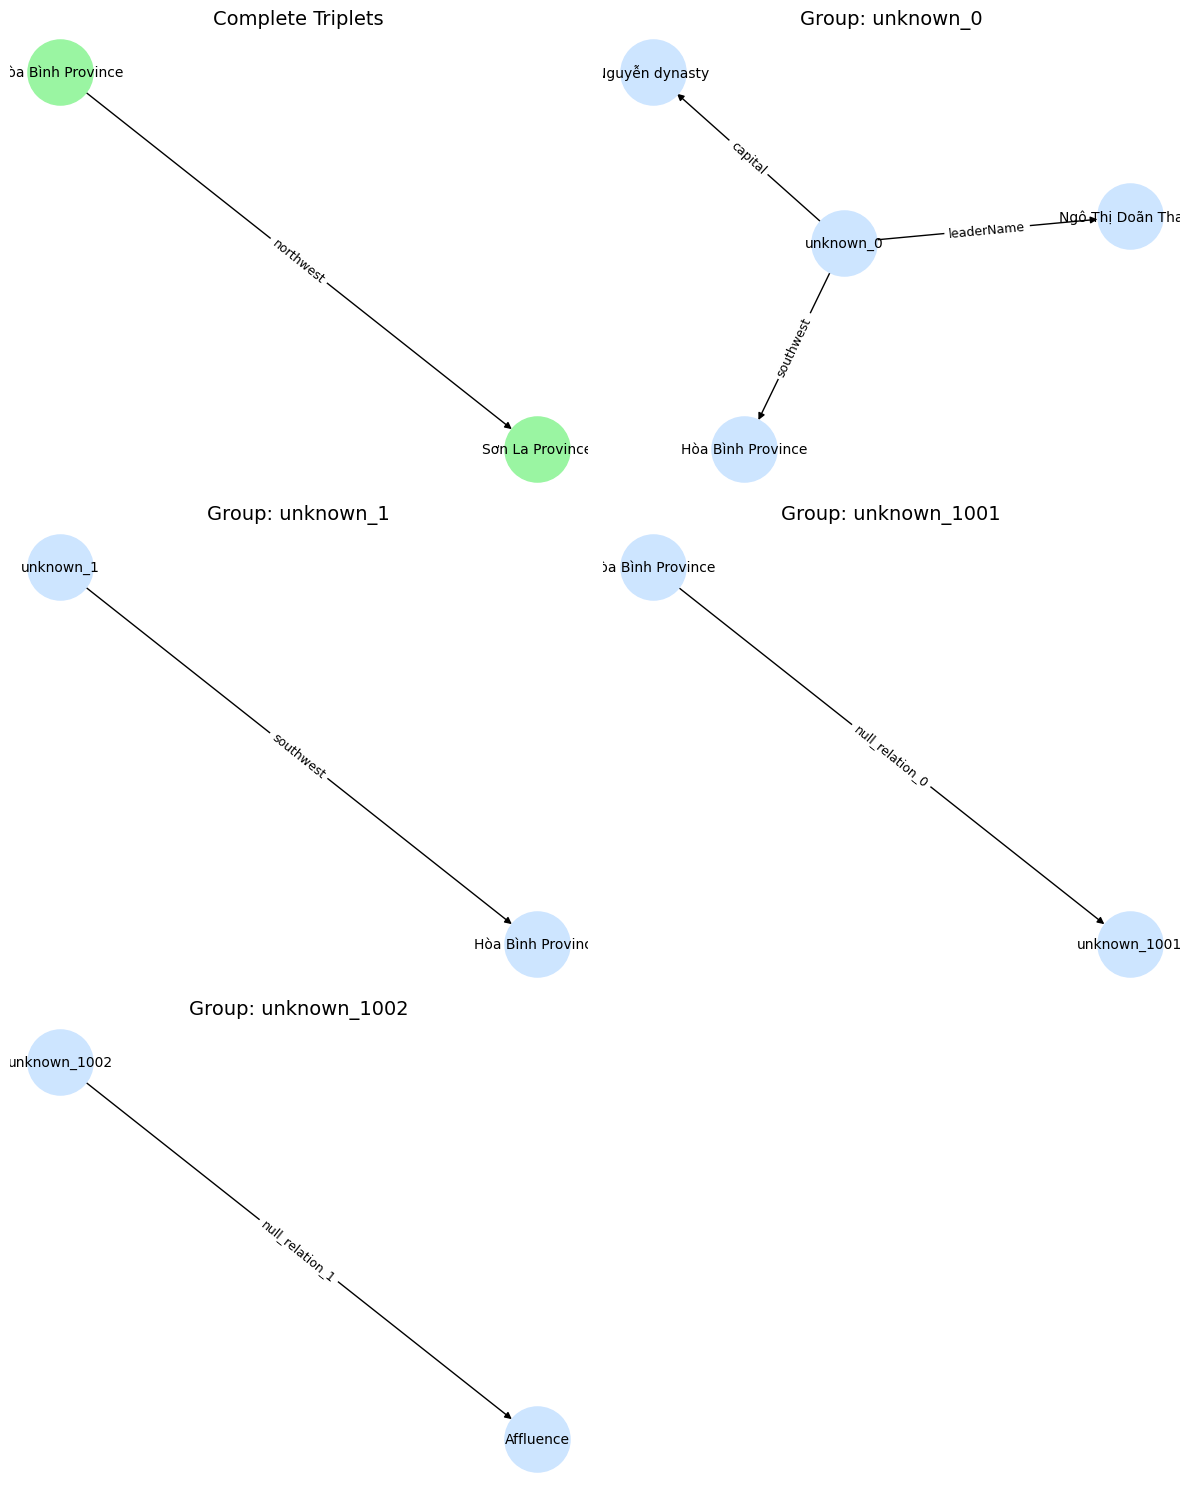

Filled unknowns with relations: [{'triplets': ['<e>Nguyễn dynasty</e>||capital||<e>Huế</e>', '<e>Ngô Thị Doãn Thanh</e>||leaderName||<e>Hanoi</e>', '<e>Hòa Bình Province</e>||southwest||<e>Hanoi</e>', '<e>Hòa Bình Province</e>||southeast||<e>Hà Nam Province</e>', '<e>Hòa Bình Province</e>||southwest||<e>Hà Nam Province</e>'], 'candidate_nodes_after_top_k': ['Hanoi', 'Huế', 'Hà Nam Province'], 'explicit_nodes': ['Ngô Thị Doãn Thanh', 'Hòa Bình Province', 'Nguyễn dynasty']}, {'triplets': ['<e>Hòa Bình Province</e>||southwest||<e>Hanoi</e>', '<e>Hòa Bình Province</e>||southeast||<e>Hà Nam Province</e>', '<e>Hòa Bình Province</e>||northwest||<e>Ninh Bình Province</e>', '<e>Hòa Bình Province</e>||southwest||<e>Hà Nam Province</e>', '<e>Hòa Bình Province</e>||southeast||<e>Ninh Bình Province</e>'], 'candidate_nodes_after_top_k': ['Hanoi', 'Hà Nam Province', 'Ninh Bình Province'], 'explicit_nodes': ['Hòa Bình Province']}]
Filled unknowns without relations: [{'triplets': ['<e>Hòa Bình Province

In [ ]:

import sys
sys.path.append('..')
from utils.sim import Similarity
from group_n_decompose import GroupNDecompose


from typing import List, Dict, Optional, Callable

from kg_connector.kg_connector import KGConnector

class RetrieveAndUnion:
    def __init__(self, kg_connector: Optional[KGConnector] = None):
        self.kg_connector = kg_connector if kg_connector else KGConnector()
        self.sim = Similarity()

    def retrieve_neighbors(self, entity_names: list[str]):
        all_neighbors = []
        retrived_neighbors = self.kg_connector.get_neighbors(entity_names)
        return retrived_neighbors

    def union_nodes(self, grouped_n_decomposed, neighbors_list: List[Dict]):
        pass

    def flatten_neighbors(self, neighbor_dict: Dict) -> List:
        """
        neighbor_dict: dict {relation: [entities]}
        → return flat candidate entity list
        """
        candidates = set()
        for rel, vals in neighbor_dict.items():
            for v in vals:
                candidates.add(v)
        return list(candidates)

    def build_candidates(self, neighbor_info: Dict) -> Dict:
        flatten_neighbors = {}
        keys = neighbor_info.keys()
        for k in keys:
            flatten_neighbors[k] = self.flatten_neighbors(neighbor_info[k])
        return flatten_neighbors

    def resolve_unknown_with_relation_2(
        self,
        neighbors: Dict[str, Dict[str, List[str]]],
        pseudo_graph: Dict) -> Dict:
        """
        Resolve all unknown entities WITH known (non-null) relations in `pseudo_graph`.

        Parameters
        ----------
        neighbors : Dict[str, Dict[str, List[str]]]
            KG adjacency list. For each entity:
                neighbors[entity] = {relation: [neighbor_entities]}
        pseudo_graph : Dict
            {
                "complete_triplets": [...],
                "incomplete_groups": {
                    unk_id: {
                        "unknown": str,
                        "explicit_entities": [...],
                        "relations": [...],
                        "raw_triplets": [...]
                    },
                    ...
                }
            }
        sim_function : callable
            Similarity function between relations, provided by the parent class.

        Returns
        -------
        pseudo_graph : Dict
            The same structure but each unknown group augmented with:
                - "candidate_entities"
                - "ranked_candidates"
                - "retrieved_triplets"
        """

        incomplete_groups = pseudo_graph.get("incomplete_groups", {})

        for unk_id, group in incomplete_groups.items():

            explicit_entities = group.get("explicit_entities", [])
            pseudo_relations = group.get("relations", [])

            # Skip if all relations are null_relation_X → handled by another function
            if all(r.startswith("null_relation") for r in pseudo_relations):
                continue

            # ---------------------------------------------------------
            # Build candidate_sets: For each explicit entity e_ui, get candidates
            # ---------------------------------------------------------
            candidate_sets = []
            for e in explicit_entities:
                if e not in neighbors:
                    candidate_sets.append([])
                    continue

                # All neighbors of e across all relations
                cand_list = []
                for rel, tails in neighbors[e].items():
                    for t in tails:
                        # skip string garbage like "Rice noodles, beef or chicken"
                        if isinstance(t, str) and "," in t and '"' in t:
                            continue
                        cand_list.append(t)

                candidate_sets.append(cand_list)

            # Build KG structure in the expected format for rank_candidates
            # KG[entity] = [(relation, neighbor)]
            KG = {}
            for e, rdict in neighbors.items():
                KG[e] = []
                for rel, vals in rdict.items():
                    for v in vals:
                        KG[e].append((rel, v))

            # ---------------------------------------------------------
            # Rank candidates using your provided ranking function
            # ---------------------------------------------------------
            ranked = self.sim.rank_candidates(
                candidate_sets=candidate_sets,
                explicit_entities=explicit_entities,
                pseudo_relations=pseudo_relations,
                KG=KG,
                sim_func=self.sim.sim,
                k1=3,
                normalize=True,
                aggregate="max",
            )

            # Save the ranked candidates for this unknown
            group["candidate_entities"] = [c for c, s in ranked]
            group["ranked_candidates"] = ranked

            # ---------------------------------------------------------
            # Expand ranked candidates into real KG triplets
            # ---------------------------------------------------------
            retrieved = []

            for (cand, score) in ranked:
                # connect candidate <-> explicit entitiy
                for e in explicit_entities:
                    if e not in neighbors:
                        continue

                    for rel, vals in neighbors[e].items():
                        for t in vals:
                            # KG: e --rel--> t
                            if t == cand:
                                retrieved.append({
                                    "head": e,
                                    "relation": rel,
                                    "tail": cand,
                                    "score": score
                                })
                            # Candidate as head
                            if cand in neighbors and cand in neighbors and cand in neighbors:
                                # check reverse edges only if exist
                                pass

            group["retrieved_triplets"] = retrieved

        return pseudo_graph

    def resolve_unknown_with_relation(
        self,
        neighbors: Dict[str, Dict[str, List[str]]],
        pseudo_graph: Dict
    ) -> List[Dict]:
        """
        ClaimPKG-compliant subgraph retrieval for unknowns WITH real relations.
        Returns only: triplets, candidate_nodes_after_top_k, explicit_nodes
        """

        incomplete_groups = pseudo_graph.get("incomplete_groups", {})
        result = []

        for unk_id, group in incomplete_groups.items():

            explicit_entities = group.get("explicit_entities", [])
            pseudo_relations  = group.get("relations", [])

            # Skip null-rel groups (paper handles separately)
            if all(r.startswith("null_relation") for r in pseudo_relations):
                continue

            # -------------------------
            # Build candidate sets Cu
            # -------------------------
            candidate_sets = []
            for e in explicit_entities:
                if e not in neighbors:
                    candidate_sets.append([])
                    continue

                cand_list = []
                for rel, vals in neighbors[e].items():
                    for v in vals:
                        if isinstance(v, str) and "," in v and '"' in v:
                            continue
                        cand_list.append(v)

                candidate_sets.append(cand_list)

            # -------------------------
            # Build KG for ranker
            # -------------------------
            KG = {
                ent: [(rel, nb) for rel, lst in rdict.items() for nb in lst]
                for ent, rdict in neighbors.items()
            }

            # -------------------------
            # Rank candidates (Eq.(5-6))
            # -------------------------
            ranked = self.sim.rank_candidates(
                candidate_sets=candidate_sets,
                explicit_entities=explicit_entities,
                pseudo_relations=pseudo_relations,
                KG=KG,
                sim_func=self.sim.sim,
                k1=3,
                normalize=True,
                aggregate="max"
            )

            top_nodes = [c for c, _ in ranked]  # top-K candidates

            # -------------------------
            # Build union graph S* (pure KG)
            # -------------------------
            S = []

            for e in explicit_entities:
                if e not in neighbors:
                    continue

                for rel, vals in neighbors[e].items():
                    for v in vals:
                        if v in top_nodes:
                            S.append(f"<e>{e}</e>||{rel}||<e>{v}</e>")

            # Deduplicate triplets
            S = list(set(S))

            # -------------------------------------------------
            # Step 4 — Append per-unknown result
            # -------------------------------------------------
            result.append({
                "triplets": S,
                "candidate_nodes_after_top_k": top_nodes,
                "explicit_nodes": explicit_entities
            })

            # Save minimal paper-compliant results
            # result["triplets"] = list(set(S))
            # result["candidate_nodes_after_top_k"] = top_nodes
            # result["explicit_nodes"] = explicit_entities

        return result

    def resolve_unknown_without_relation(
        self,
        neighbors: Dict[str, Dict[str, List[str]]],
        pseudo_graph: Dict,
        k1: int = 3
    ) -> List[Dict]:
        """
        Resolve unknown entities whose relations are null_relation_X.
        According to ClaimPKG, null-rel groups use frequency-based scoring
        instead of relation-aware ranking.

        Returns a list of dicts:
        [
            {
                "triplets": [...],
                "candidate_nodes_after_top_k": [...],
                "explicit_nodes": [...]
            },
            ...
        ]
        """

        incomplete_groups = pseudo_graph.get("incomplete_groups", {})
        results = []

        for unk_id, group in incomplete_groups.items():

            explicit_entities = group.get("explicit_entities", [])
            pseudo_relations  = group.get("relations", [])

            # Only handle groups where ALL relations are null_relation_x
            if not all(r.startswith("null_relation") for r in pseudo_relations):
                continue

            # -------------------------------------------------
            # Step 1 — Collect candidate sets (neighbors only)
            # -------------------------------------------------
            candidate_list = []   # flatten all candidates
            candidate_sets = []   # keep per-entity lists

            for e in explicit_entities:
                if e not in neighbors:
                    candidate_sets.append([])
                    continue

                cand = []
                for rel, vals in neighbors[e].items():
                    for v in vals:
                        if isinstance(v, str) and "," in v and '"' in v:
                            continue
                        cand.append(v)

                candidate_sets.append(cand)
                candidate_list.extend(cand)

            # -------------------------------------------------
            # Step 2 — Frequency-based scoring (ClaimPKG null-rel)
            # -------------------------------------------------
            from collections import Counter

            freq = Counter(candidate_list)
            top_candidates = [c for c, _ in freq.most_common(k1)]

            # -------------------------------------------------
            # Step 3 — Build union subgraph S* (KG-only)
            # -------------------------------------------------
            S = []

            for e in explicit_entities:
                if e not in neighbors:
                    continue

                for rel, vals in neighbors[e].items():
                    for v in vals:
                        if v in top_candidates:
                            S.append(f"<e>{e}</e>||{rel}||<e>{v}</e>")

            # Deduplicate triplets
            S = list(set(S))

            # -------------------------------------------------
            # Step 4 — Append per-unknown result
            # -------------------------------------------------
            results.append({
                "triplets": S,
                "candidate_nodes_after_top_k": top_candidates,
                "explicit_nodes": explicit_entities
            })

        return results

    def retrive_and_union(self, standardized_triplets: List[str]):
        entities = set()
        triplet_tuples = []
        



# Main
if __name__ == "__main__":
    claim = "Hòa Bình Province is in the southwest of the city led by Ngô Thị Doãn Thanh, whose capital was established by the Nguyễn dynasty and is nicknamed 'Affluence'. It is northwest of Sơn La Province."
    triplets = [
        "<e>unknown_0</e> || leaderName || <e>Ngô Thị Doãn Thanh</e>",
        "<e>unknown_0</e> || southwest || <e>Hòa Bình Province</e>",
        "<e>unknown_1</e> || southwest || <e>Hòa Bình Province</e>",
        "<e>Hòa Bình Province</e> || nickname || <e>Affluence</e>",
        "<e>Hòa Bình Province</e> || northwest || <e>Sơn La Province</e>",
        "<e>unknown_0</e> || capital || <e>Nguyễn dynasty</e>",
    ]
    gnd = GroupNDecompose()
    grouped_decomposed = gnd.group_n_decompose(triplets)
    # Plot grouped_decomposed
    gnd.visualize_groups(grouped_decomposed)
    retriever = RetrieveAndUnion()
    entity_names = ["Ngô Thị Doãn Thanh", "Hòa Bình Province", "Nguyễn dynasty", "Sơn La Province", "Affluence"]
    neighbors = retriever.retrieve_neighbors(entity_names)
    candidates = retriever.build_candidates(neighbors)
    filled_unk_with_relations = retriever.resolve_unknown_with_relation(
        neighbors=neighbors,
        pseudo_graph=grouped_decomposed,
    )

    filled_unk_without_relations = retriever.resolve_unknown_without_relation(
        neighbors=neighbors,
        pseudo_graph=grouped_decomposed,
    )
    print("Filled unknowns with relations:", filled_unk_with_relations)
    print("Filled unknowns without relations:", filled_unk_without_relations)

In [16]:

def union_triplets(filled_with_rel, filled_without_rel):
    """
    Union các triplet từ 2 danh sách:
    - filled_with_rel: candidate đã có relation
    - filled_without_rel: candidate chưa có relation

    Trả về danh sách object:
    [{"triplet_as_string": str, "explicit_node": [str]}]
    """
    result = []

    # Hàm xử lý từng nhóm
    def process_group(group):
        triplets = group.get("triplets", [])
        explicit_nodes = group.get("explicit_nodes", [])
        for t in triplets:
            result.append({
                "triplet_as_string": t,
                "explicit_node": explicit_nodes
            })

    # Xử lý tất cả nhóm
    for group in filled_with_rel:
        process_group(group)

    for group in filled_without_rel:
        process_group(group)

    return result

graph_union = union_triplets(filled_unk_with_relations, filled_unk_without_relations)

for item in graph_union:
    print(item)


{'triplet_as_string': '<e>Nguyễn dynasty</e>||capital||<e>Huế</e>', 'explicit_node': ['Ngô Thị Doãn Thanh', 'Hòa Bình Province', 'Nguyễn dynasty']}
{'triplet_as_string': '<e>Ngô Thị Doãn Thanh</e>||leaderName||<e>Hanoi</e>', 'explicit_node': ['Ngô Thị Doãn Thanh', 'Hòa Bình Province', 'Nguyễn dynasty']}
{'triplet_as_string': '<e>Hòa Bình Province</e>||southwest||<e>Hanoi</e>', 'explicit_node': ['Ngô Thị Doãn Thanh', 'Hòa Bình Province', 'Nguyễn dynasty']}
{'triplet_as_string': '<e>Hòa Bình Province</e>||southeast||<e>Hà Nam Province</e>', 'explicit_node': ['Ngô Thị Doãn Thanh', 'Hòa Bình Province', 'Nguyễn dynasty']}
{'triplet_as_string': '<e>Hòa Bình Province</e>||southwest||<e>Hà Nam Province</e>', 'explicit_node': ['Ngô Thị Doãn Thanh', 'Hòa Bình Province', 'Nguyễn dynasty']}
{'triplet_as_string': '<e>Hòa Bình Province</e>||southwest||<e>Hanoi</e>', 'explicit_node': ['Hòa Bình Province']}
{'triplet_as_string': '<e>Hòa Bình Province</e>||southeast||<e>Hà Nam Province</e>', 'explicit_

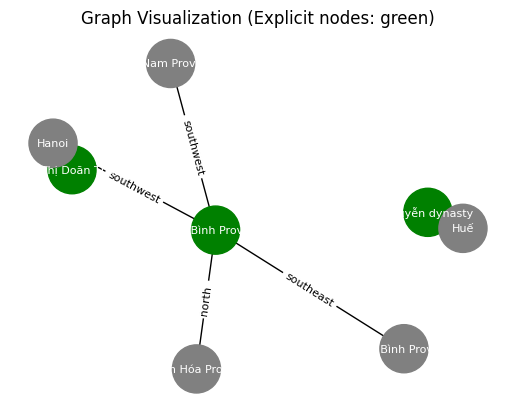

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph_logic(triplets_list):
    """
    Visualize KG graph theo logic:
    1. Tìm tất cả nodes và đánh dấu explicit hay không
    2. Lặp qua từng triplet, nối nodes với edge hiển thị relation
    """
    G = nx.DiGraph()

    # 1. Thu thập tất cả nodes và đánh dấu explicit
    node_info = {}  # node -> is_explicit
    for item in triplets_list:
        for node in item["explicit_node"]:
            node_clean = node.strip()
            node_info[node_clean] = True

    # Thêm tất cả nodes từ triplets, nếu chưa có explicit thì mặc định False
    for item in triplets_list:
        triplet = item["triplet_as_string"]
        try:
            head, relation, tail = triplet.split("||")
            head = head.replace("<e>", "").replace("</e>", "").strip()
            tail = tail.replace("<e>", "").replace("</e>", "").strip()
            relation = relation.strip()
        except ValueError:
            continue

        if head not in node_info:
            node_info[head] = False
        if tail not in node_info:
            node_info[tail] = False

        G.add_edge(head, tail, label=relation)

    # 2. Vẽ nodes với màu explicit/không explicit
    node_colors = ["green" if node_info[n] else "gray" for n in G.nodes()]
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1200)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="white")

    # Vẽ edges và relation
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=10, edge_color='black')
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.axis("off")
    plt.title("Graph Visualization (Explicit nodes: green)")
    plt.show()


# Sử dụng ví dụ
visualize_graph_logic(graph_union)
